# NHR

## $ HNR = \frac{E_{harmonic}}{E_{noise}} $

### $ E_{harmonic} = $ Energy  at fundamental frequency  and its integer multiples
### $ E_{noise}= $ Energy energy that is not periodic (random, aperiodic, turbulent)


## $ HNR\_dB = 10 \times log_{10} ^{NHR} $

In [1]:
import numpy as np
from scipy.signal import find_peaks

In [9]:
def HNR(x, sr):

    # find the fundamental frequency Energy

    D = np.fft.rfft(x)
    mag = np.abs(D)

    peaks, _ = find_peaks(mag, height=np.mean(mag))

    if len(peaks) > 0 :
        
        peakEnergy = np.sum(mag[peaks])
        
    else:
        return 0

    # calculating noise energy
    totalEnergy = np.sum(mag)
    noiseEnergy = totalEnergy - peakEnergy

    # HNR

    if noiseEnergy >0:
        hnr = peakEnergy/noiseEnergy
        hnr_dB = 10 * np.log10(hnr)

        return float(hnr), float(hnr_dB)

    return None, None
    
    

In [10]:
sr = 16000
t = np.linspace(0, 1, sr)
x = np.sin(2*np.pi*150*t) + 0.1*np.random.randn(len(t))

In [11]:
HNR(x, sr)

(0.8437073232746575, -0.7380818125433225)

In [12]:
t

array([0.00000000e+00, 6.25039065e-05, 1.25007813e-04, ...,
       9.99874992e-01, 9.99937496e-01, 1.00000000e+00])

In [15]:
x

array([ 0.04807474,  0.00127257,  0.18333509, ..., -0.08602761,
       -0.00589612,  0.11734393])

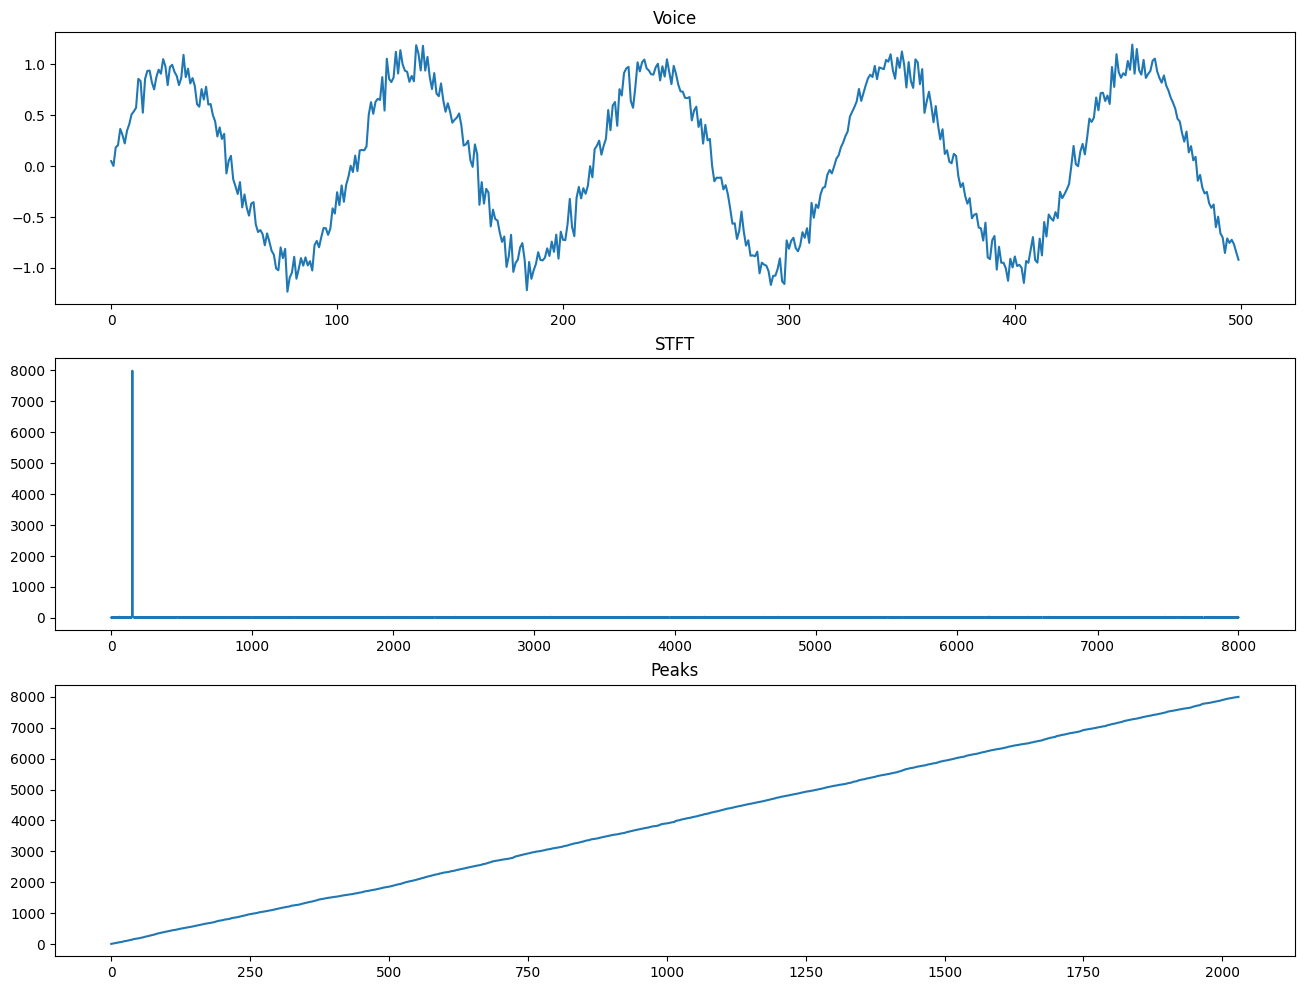

In [49]:
import matplotlib.pyplot as plt


D = np.fft.rfft(x)
mag = np.abs(D)
peaks, _ = find_peaks(mag, height=np.mean(mag))
peakEnergy = np.sum(mag[peaks])

plt.figure(figsize=(16,12))

plt.subplot(311)
plt.title("Voice")
plt.plot(x[:500])

plt.subplot(312)
plt.title("STFT")
plt.plot(mag)


plt.subplot(313)
plt.title("Peaks")
plt.plot(peaks)
